<a href="https://colab.research.google.com/github/Ariqueeezz/Enterprise-Brand-Sentiment-and-Campaign-Analytics-Pipeline/blob/epic%2FEBSCAP-9/Epic_EBSCAP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving torch_ready_checkpoint.zip to torch_ready_checkpoint.zip


In [5]:
import zipfile
import os

torch_dir = "/content/torch_ready"
os.makedirs(torch_dir, exist_ok=True)

with zipfile.ZipFile("torch_ready_checkpoint.zip", "r") as zip_ref:
    zip_ref.extractall(torch_dir)

print("Isi folder torch_ready:")
print(os.listdir(torch_dir))

Isi folder torch_ready:
['y_val.npy', 'X_val.npy', 'y_test.npy', 'X_test.npy', 'X_train.npy', 'y_train.npy', 'embedding_matrix.npy', 'word2idx.pkl']


In [6]:
import numpy as np
import pickle
import torch
from torch.utils.data import Dataset, DataLoader

embedding_matrix = np.load(f"{torch_dir}/embedding_matrix.npy")
X_train = np.load(f"{torch_dir}/X_train.npy")
X_val = np.load(f"{torch_dir}/X_val.npy")
X_test = np.load(f"{torch_dir}/X_test.npy")
y_train = np.load(f"{torch_dir}/y_train.npy")
y_val = np.load(f"{torch_dir}/y_val.npy")
y_test = np.load(f"{torch_dir}/y_test.npy")

with open(f"{torch_dir}/word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Vocab size: {len(word2idx)}")

Embedding matrix shape: (47016, 100)
X_train shape: (489937, 100), y_train shape: (489937,)
Vocab size: 47016


# **EBSCAP-12: Rancang arsitektur model sekuensial (Bi-LSTM dengan Attention atau DistilBERT)**

In [7]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [8]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SentimentDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=BATCH_SIZE)

xb, yb = next(iter(train_loader))
print(f"Sanity check batch shape: {xb.shape}, {yb.shape}")

Sanity check batch shape: torch.Size([64, 100]), torch.Size([64])


In [9]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)  # *2 karena bidirectional

    def forward(self, lstm_output, mask):
        scores = self.attn(lstm_output).squeeze(-1)          # [batch, seq_len]
        scores = scores.masked_fill(mask == 0, -1e9)          # abaikan posisi PAD
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(lstm_output * weights.unsqueeze(-1), dim=1)
        return context, weights

In [10]:
class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_classes=3,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = Attention(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.pad_idx = pad_idx

    def forward(self, x):
        mask = (x != self.pad_idx).float()
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        context, attn_weights = self.attention(lstm_out, mask)
        out = self.dropout(context)
        logits = self.fc(out)
        return logits, attn_weights

In [11]:
PAD_IDX = word2idx["<PAD>"]

model = BiLSTMAttentionClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    num_classes=3,
    dropout=0.3,
    pad_idx=PAD_IDX
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

BiLSTMAttentionClassifier(
  (embedding): Embedding(47016, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)
Total params: 4,938,148 | Trainable: 4,938,148


In [12]:
xb, yb = xb.to(device), yb.to(device)

logits, attn_weights = model(xb)
print(f"Logits shape: {logits.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"Attention weights sum per sample (~1.0): {attn_weights.sum(dim=1)[:5]}")

Logits shape: torch.Size([64, 3])
Attention weights shape: torch.Size([64, 100])
Attention weights sum per sample (~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)


# **EBSCAP 13: Eksekusi training batch historis dan optimasi model**

In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch.optim as optim
import copy

In [14]:
from collections import Counter

class_counts = Counter(y_train.tolist())
print(f"Distribusi kelas di training set: {class_counts}")

total = sum(class_counts.values())
class_weights = torch.tensor(
    [total / class_counts[i] for i in range(3)],
    dtype=torch.float32
).to(device)

print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Distribusi kelas di training set: Counter({2: 349140, 0: 101416, 1: 39381})
Class weights: tensor([ 4.8310, 12.4409,  1.4033])


In [15]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")  # macro: perlakukan tiap kelas setara
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1_macro, f1_weighted, all_preds, all_labels

In [16]:
NUM_EPOCHS = 20
PATIENCE = 3  # stop kalau val F1 macro tidak membaik selama 3 epoch berturut-turut

best_val_f1 = -1
patience_counter = 0
best_model_state = None

history = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1_macro": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # cegah exploding gradient
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, val_acc, val_f1_macro, val_f1_weighted, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1_macro"].append(val_f1_macro)

    print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1 (macro): {val_f1_macro:.4f}")

    # Early stopping check
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  → Model membaik, checkpoint disimpan.")
    else:
        patience_counter += 1
        print(f"  → Tidak membaik ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping dipicu di epoch {epoch}.")
            break

# Load kembali bobot terbaik (bukan bobot epoch terakhir)
model.load_state_dict(best_model_state)
print(f"\nBest Val F1 (macro): {best_val_f1:.4f}")

Epoch  1 | Train Loss: 0.6152 | Val Loss: 0.5733 | Val Acc: 0.8036 | Val F1 (macro): 0.6852
  → Model membaik, checkpoint disimpan.
Epoch  2 | Train Loss: 0.5206 | Val Loss: 0.5729 | Val Acc: 0.8278 | Val F1 (macro): 0.7011
  → Model membaik, checkpoint disimpan.
Epoch  3 | Train Loss: 0.4542 | Val Loss: 0.6073 | Val Acc: 0.8166 | Val F1 (macro): 0.6919
  → Tidak membaik (1/3)
Epoch  4 | Train Loss: 0.3876 | Val Loss: 0.6674 | Val Acc: 0.8165 | Val F1 (macro): 0.6871
  → Tidak membaik (2/3)
Epoch  5 | Train Loss: 0.3246 | Val Loss: 0.7704 | Val Acc: 0.8290 | Val F1 (macro): 0.6916
  → Tidak membaik (3/3)

Early stopping dipicu di epoch 5.

Best Val F1 (macro): 0.7011


In [17]:
test_loss, test_acc, test_f1_macro, test_f1_weighted, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n=== Hasil Test Set ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 (macro): {test_f1_macro:.4f}")
print(f"F1 (weighted): {test_f1_weighted:.4f}")

label_names = ["Negatif", "Netral", "Positif"]
print("\n" + classification_report(test_labels, test_preds, target_names=label_names))


=== Hasil Test Set ===
Accuracy: 0.8281
F1 (macro): 0.7013
F1 (weighted): 0.8497

              precision    recall  f1-score   support

     Negatif       0.82      0.76      0.79     21732
      Netral       0.29      0.61      0.40      8439
     Positif       0.97      0.87      0.92     74816

    accuracy                           0.83    104987
   macro avg       0.69      0.75      0.70    104987
weighted avg       0.88      0.83      0.85    104987



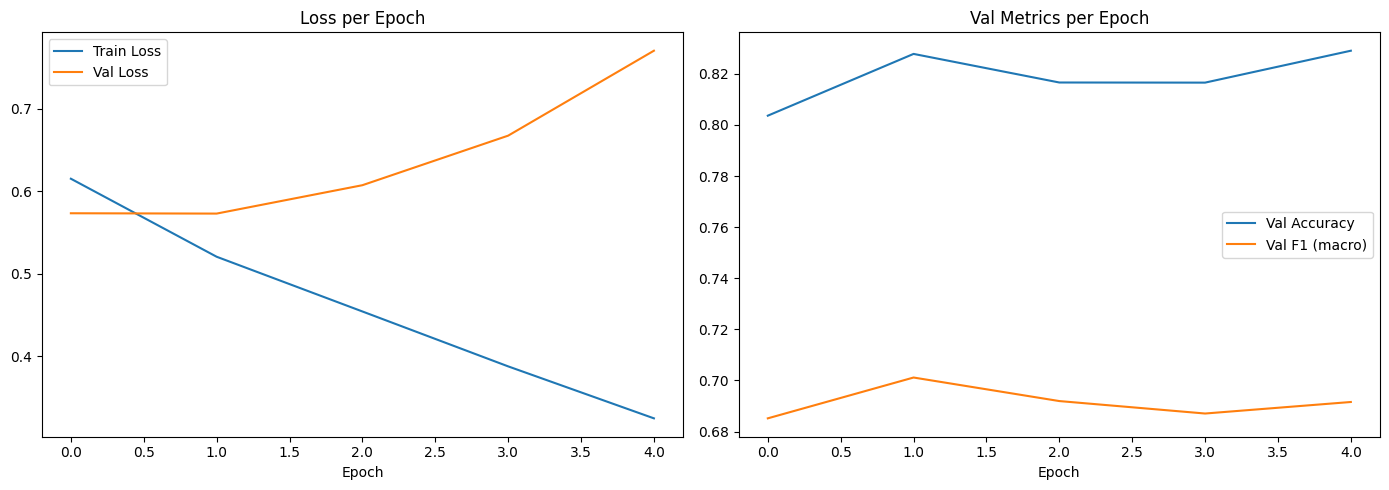

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Val Accuracy")
axes[1].plot(history["val_f1_macro"], label="Val F1 (macro)")
axes[1].set_title("Val Metrics per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
model_dir = "/content/model_ready"
os.makedirs(model_dir, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "hidden_dim": 128,
    "num_classes": 3,
    "dropout": 0.3,
    "pad_idx": PAD_IDX,
    "embedding_dim": embedding_matrix.shape[1],
    "vocab_size": embedding_matrix.shape[0],
}, f"{model_dir}/bilstm_attention_model.pt")

import pickle
with open(f"{model_dir}/training_history.pkl", "wb") as f:
    pickle.dump(history, f)

import shutil
from google.colab import files
shutil.make_archive("/content/model_ready_checkpoint", "zip", model_dir)
files.download("/content/model_ready_checkpoint.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Reverse mapping: index -> kata
idx2word = {idx: word for word, idx in word2idx.items()}

def decode_indices(indices, idx2word):
    words = [idx2word.get(idx, "<UNK>") for idx in indices if idx2word.get(idx) != "<PAD>"]
    return " ".join(words)

test_texts = [decode_indices(seq, idx2word) for seq in X_test]

print("Contoh hasil decode:")
for t in test_texts[:3]:
    print(t[:150])
    print("---")

Contoh hasil decode:
great size purse. wonderful smell!
---
miss jessie ' quick curls <UNK> pillow soft curls much better. wouldn't buy product ...
---
go well stay several days. friend recently bought another brand metallic tattoos, difference quality evident.
---


In [21]:
import pandas as pd

NETRAL_LABEL = 1
label_names = ["Negatif", "Netral", "Positif"]

results_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [label_names[l] for l in test_labels],
    "pred_label": [label_names[p] for p in test_preds],
    "true_raw": test_labels,
    "pred_raw": test_preds,
})

# Kasus 1: Model salah prediksi jadi Netral padahal aslinya bukan (False Positive Netral)
fp_netral = results_df[(results_df["pred_raw"] == NETRAL_LABEL) & (results_df["true_raw"] != NETRAL_LABEL)]

# Kasus 2: Aslinya Netral tapi model prediksi kelas lain (False Negative Netral)
fn_netral = results_df[(results_df["true_raw"] == NETRAL_LABEL) & (results_df["pred_raw"] != NETRAL_LABEL)]

print(f"Jumlah False Positive Netral (harusnya bukan Netral): {len(fp_netral)}")
print(f"Jumlah False Negative Netral (harusnya Netral): {len(fn_netral)}")

Jumlah False Positive Netral (harusnya bukan Netral): 12398
Jumlah False Negative Netral (harusnya Netral): 3302


In [22]:
print("=== CONTOH: Model bilang Netral, padahal aslinya... ===\n")
for _, row in fp_netral.sample(10, random_state=1).iterrows():
    print(f"[Asli: {row['true_label']}] → [Prediksi: Netral]")
    print(f"  Teks: {row['text'][:200]}")
    print()

print("\n=== CONTOH: Aslinya Netral, tapi model salah bilang... ===\n")
for _, row in fn_netral.sample(10, random_state=1).iterrows():
    print(f"[Asli: Netral] → [Prediksi: {row['pred_label']}]")
    print(f"  Teks: {row['text'][:200]}")
    print()

=== CONTOH: Model bilang Netral, padahal aslinya... ===

[Asli: Negatif] → [Prediksi: Netral]
  Teks: 

[Asli: Negatif] → [Prediksi: Netral]
  Teks: love acure face wash, scrub, lotion used fact natural, really disappointed shampoo. another reviewer mentioned, leaves hair feeling really greasy damp weird film even rinse well blow dry. tried differ

[Asli: Positif] → [Prediksi: Netral]
  Teks: like earrings <UNK> little difficult put since 3 pieces <UNK> still like

[Asli: Negatif] → [Prediksi: Netral]
  Teks: not great quality

[Asli: Positif] → [Prediksi: Netral]
  Teks: need do, strong rubbery smell first.

[Asli: Negatif] → [Prediksi: Netral]
  Teks: hair thin ends. need least four packs full hair.

[Asli: Positif] → [Prediksi: Netral]
  Teks: adult smaller head. 19 inch circumference. wig fits great. didn't need use straps. <UNK> wearing wig days found cheap. like cap shows hair peach wig pink. totally tell wig on. ok kids one night costum

[Asli: Positif] → [Prediksi: Netral]
  Te

In [23]:
print("Distribusi asli dari False Positive Netral (harusnya kelas apa):")
print(fp_netral["true_label"].value_counts())

print("\nDistribusi prediksi dari False Negative Netral (Netral dikira kelas apa):")
print(fn_netral["pred_label"].value_counts())

Distribusi asli dari False Positive Netral (harusnya kelas apa):
true_label
Positif    7958
Negatif    4440
Name: count, dtype: int64

Distribusi prediksi dari False Negative Netral (Netral dikira kelas apa):
pred_label
Negatif    1995
Positif    1307
Name: count, dtype: int64


In [24]:
results_df["text_len"] = results_df["text"].apply(lambda t: len(t.split()))
print(results_df.groupby(["true_label", "pred_label" if False else "true_label"])["text_len"].describe())
print(results_df.groupby("true_label")["text_len"].mean())

                         count       mean        std  min  25%   50%   75%  \
true_label true_label                                                        
Negatif    Negatif     21732.0  16.849577  16.809674  0.0  6.0  12.0  21.0   
Netral     Netral       8439.0  19.212347  19.508233  0.0  7.0  13.0  24.0   
Positif    Positif     74816.0  16.461252  18.755048  0.0  5.0  10.0  21.0   

                         max  
true_label true_label         
Negatif    Negatif     100.0  
Netral     Netral      100.0  
Positif    Positif     100.0  
true_label
Negatif    16.849577
Netral     19.212347
Positif    16.461252
Name: text_len, dtype: float64


## Catatan Limitasi — Klasifikasi Kelas Netral

**Temuan:** Model Bi-LSTM+Attention mencapai performa kuat pada kelas Positif (F1 0.92)
dan Negatif (F1 0.80), namun signifikan lebih rendah pada kelas Netral (F1 0.40,
precision 0.30, recall 0.61).

**Analisis akar masalah:**
Investigasi manual terhadap sampel kesalahan klasifikasi menunjukkan confusion terjadi
simetris antara Netral↔Negatif dan Netral↔Positif (bukan bias satu arah), dan tidak
berkorelasi dengan panjang teks (rata-rata word count antar kelas relatif setara,
16-19 kata). Pemeriksaan langsung terhadap teks yang salah klasifikasi menunjukkan
bahwa mayoritas kesalahan terjadi pada:
1. Review dengan sentimen campuran (pujian + komplain dalam satu teks, mis. rating
   4 bintang dengan catatan negatif minor).
2. Review sangat singkat tanpa sinyal leksikal sentimen yang eksplisit.

**Kesimpulan:** Pola ini mengindikasikan keterbatasan berasal dari **noise pada
label**, bukan murni kelemahan arsitektur model — rating bintang sebagai proxy
label sentimen bersifat inherently ambigu di sekitar batas kelas (3-4 bintang,
2-3 bintang), sebuah fenomena yang telah didokumentasikan dalam literatur NLP
sentiment analysis berbasis rating.

**Rekomendasi untuk pengembangan lanjutan:** class weighting berbasis rasio penuh
(`total/class_count`) berpotensi over-correct dan menurunkan precision kelas
minoritas; pendekatan weighting yang lebih moderat (mis. inverse-sqrt frequency)
atau agregasi label (binary positif/negatif) dapat dieksplorasi sebagai perbaikan
di luar cakupan sprint ini.

# **EBSCAP 15: Desain skema incremental gradient descent / partial_fit**

In [25]:
import copy
import torch
import torch.nn as nn

# Kalau variabel `model` masih ada dari Task 3.3 dan sudah di-load_state_dict(best_model_state),
# tidak perlu load ulang dari file. Cek dulu:
print(model)

BiLSTMAttentionClassifier(
  (embedding): Embedding(47016, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


In [26]:
checkpoint = torch.load("/content/model_ready/bilstm_attention_model.pt", map_location=device)
model = BiLSTMAttentionClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=checkpoint["hidden_dim"],
    num_classes=checkpoint["num_classes"],
    dropout=checkpoint["dropout"],
    pad_idx=checkpoint["pad_idx"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [27]:
baseline_model_state = copy.deepcopy(model.state_dict())
print("Baseline weights (pre-online-learning) tersimpan.")

Baseline weights (pre-online-learning) tersimpan.


In [28]:
def partial_fit(model, optimizer, criterion, x_batch, y_batch, device, max_grad_norm=5.0):
    """
    Satu langkah update incremental menggunakan micro-batch feedback baru.
    x_batch: [batch_size, seq_len] — token indices
    y_batch: [batch_size] — label sentimen (0=Negatif, 1=Netral, 2=Positif)
    """
    model.train()
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    optimizer.zero_grad()
    logits, _ = model(x_batch)
    loss = criterion(logits, y_batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
    optimizer.step()

    return loss.item()

In [29]:
ONLINE_LR = 1e-5  # 100x lebih kecil dari LR training awal (1e-3), cegah update drastis dari satu micro-batch

online_optimizer = torch.optim.Adam(model.parameters(), lr=ONLINE_LR)
online_criterion = nn.CrossEntropyLoss()  # tanpa class weight — asumsi feedback baru natural, tidak di-oversample

In [30]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.8 MB/s eta 0:00:00


In [31]:
import re
import emoji

MAX_LEN = 100  # harus sama persis dengan yang dipakai di Task 3.1

def preprocess_new_review(text, word2idx, custom_stopwords, max_len=MAX_LEN):
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = emoji.replace_emoji(text, replace=' ')
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()

    tokens = [t for t in text.split(" ") if t not in custom_stopwords and t != ""]

    unk_idx = word2idx["<UNK>"]
    pad_idx = word2idx["<PAD>"]
    indices = [word2idx.get(t, unk_idx) for t in tokens][:max_len]
    if len(indices) < max_len:
        indices += [pad_idx] * (max_len - len(indices))

    return torch.tensor([indices], dtype=torch.long)

In [32]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StopWordsRemover

spark = (
    SparkSession.builder
    .appName("BrandSentimentPipeline")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

default_stopwords = StopWordsRemover.loadDefaultStopWords("english")

negation_words = {"not", "no", "nor", "never", "none", "neither",
                   "don't", "doesn't", "didn't", "won't", "wouldn't",
                   "can't", "cannot", "isn't", "aren't", "wasn't", "weren't"}

custom_stopwords = [w for w in default_stopwords if w not in negation_words]
print(f"Jumlah stopwords: {len(custom_stopwords)}")

Jumlah stopwords: 167


In [33]:
import pickle

with open("/content/custom_stopwords.pkl", "wb") as f:
    pickle.dump(custom_stopwords, f)

print("Tersimpan. Spark tidak dibutuhkan lagi untuk Task 4 seterusnya.")

Tersimpan. Spark tidak dibutuhkan lagi untuk Task 4 seterusnya.


In [34]:
import pickle

with open("/content/custom_stopwords.pkl", "rb") as f:
    custom_stopwords = pickle.load(f)

In [35]:
sample_text = "This product broke after just two days, very disappointed."
sample_label = torch.tensor([0])  # 0 = Negatif (misal ini feedback koreksi dari user)

x_new = preprocess_new_review(sample_text, word2idx, custom_stopwords)

# Cek prediksi SEBELUM update
model.eval()
with torch.no_grad():
    logits_before, _ = model(x_new.to(device))
    pred_before = torch.argmax(logits_before, dim=1).item()

label_names = ["Negatif", "Netral", "Positif"]
print(f"Prediksi sebelum update: {label_names[pred_before]}")

# Lakukan satu langkah partial_fit
loss = partial_fit(model, online_optimizer, online_criterion, x_new, sample_label, device)
print(f"Loss dari update ini: {loss:.4f}")

# Cek prediksi SETELAH update
model.eval()
with torch.no_grad():
    logits_after, _ = model(x_new.to(device))
    pred_after = torch.argmax(logits_after, dim=1).item()

print(f"Prediksi setelah update: {label_names[pred_after]}")

Prediksi sebelum update: Negatif
Loss dari update ini: 0.0828
Prediksi setelah update: Negatif


In [36]:
sample_text = "This product broke after just two days, very disappointed."
sample_label = torch.tensor([0])  # 0 = Negatif (misal ini feedback koreksi dari user)

x_new = preprocess_new_review(sample_text, word2idx, custom_stopwords)

# Cek prediksi SEBELUM update
model.eval()
with torch.no_grad():
    logits_before, _ = model(x_new.to(device))
    pred_before = torch.argmax(logits_before, dim=1).item()

label_names = ["Negatif", "Netral", "Positif"]
print(f"Prediksi sebelum update: {label_names[pred_before]}")

# Lakukan satu langkah partial_fit
loss = partial_fit(model, online_optimizer, online_criterion, x_new, sample_label, device)
print(f"Loss dari update ini: {loss:.4f}")

# Cek prediksi SETELAH update
model.eval()
with torch.no_grad():
    logits_after, _ = model(x_new.to(device))
    pred_after = torch.argmax(logits_after, dim=1).item()

print(f"Prediksi setelah update: {label_names[pred_after]}")

Prediksi sebelum update: Negatif
Loss dari update ini: 0.0784
Prediksi setelah update: Negatif


In [37]:
online_learning_dir = "/content/online_learning_ready"
import os
os.makedirs(online_learning_dir, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "baseline_state_dict": baseline_model_state,
    "hidden_dim": checkpoint["hidden_dim"] if 'checkpoint' in dir() else 128,
    "num_classes": 3,
    "dropout": checkpoint["dropout"] if 'checkpoint' in dir() else 0.3,
    "pad_idx": PAD_IDX,
}, f"{online_learning_dir}/online_learning_checkpoint.pt")

print("Checkpoint online learning tersimpan.")

Checkpoint online learning tersimpan.


In [38]:
spark.stop()

# **EBSCAP 16: Setup buffer data/queue untuk penampungan feedback**

In [39]:
from collections import deque
import torch
import pickle
import os
import time

class FeedbackBuffer:
    def __init__(self, min_batch_size=16, max_buffer_size=128, persist_path=None):
        """
        min_batch_size: jumlah minimum sample sebelum trigger update
        max_buffer_size: batas atas buffer (safety, cegah memory membengkak kalau update jarang jalan)
        persist_path: kalau diisi, buffer akan di-backup ke disk (opsional, utk robustness)
        """
        self.buffer = deque()
        self.min_batch_size = min_batch_size
        self.max_buffer_size = max_buffer_size
        self.persist_path = persist_path
        self.total_received = 0

        if persist_path and os.path.exists(persist_path):
            self._load()

    def add(self, text, label):
        """Tambah 1 feedback baru ke buffer."""
        if not isinstance(label, int) or label not in [0, 1, 2]:
            raise ValueError(f"Label tidak valid: {label}. Harus 0 (Negatif), 1 (Netral), atau 2 (Positif).")

        self.buffer.append({"text": text, "label": label, "timestamp": time.time()})
        self.total_received += 1

        # Safety: kalau buffer kelebihan kapasitas (misal update loop gagal jalan lama), buang yang paling lama
        if len(self.buffer) > self.max_buffer_size:
            dropped = self.buffer.popleft()
            print(f"[WARNING] Buffer penuh, membuang feedback tertua: '{dropped['text'][:50]}...'")

        if self.persist_path:
            self._save()

    def is_ready(self):
        """Cek apakah buffer sudah cukup penuh untuk trigger update."""
        return len(self.buffer) >= self.min_batch_size

    def get_batch_and_clear(self):
        """Ambil semua isi buffer saat ini sebagai batch, lalu kosongkan buffer."""
        batch = list(self.buffer)
        self.buffer.clear()
        if self.persist_path:
            self._save()
        return batch

    def __len__(self):
        return len(self.buffer)

    def _save(self):
        with open(self.persist_path, "wb") as f:
            pickle.dump(list(self.buffer), f)

    def _load(self):
        with open(self.persist_path, "rb") as f:
            loaded = pickle.load(f)
            self.buffer = deque(loaded)
        print(f"Buffer di-restore dari disk: {len(self.buffer)} feedback pending.")

In [40]:
def trigger_buffered_update(buffer: FeedbackBuffer, model, optimizer, criterion,
                              word2idx, custom_stopwords, device, max_len=MAX_LEN):
    """
    Cek apakah buffer sudah siap, kalau ya proses seluruh batch dan update model.
    Return: (updated: bool, avg_loss: float atau None)
    """
    if not buffer.is_ready():
        return False, None

    batch_data = buffer.get_batch_and_clear()
    texts = [item["text"] for item in batch_data]
    labels = [item["label"] for item in batch_data]

    # Preprocess semua teks jadi satu tensor batch
    x_list = [preprocess_new_review(t, word2idx, custom_stopwords, max_len) for t in texts]
    x_batch = torch.cat(x_list, dim=0)  # [batch_size, seq_len]
    y_batch = torch.tensor(labels, dtype=torch.long)

    loss = partial_fit(model, optimizer, criterion, x_batch, y_batch, device)

    print(f"[UPDATE TRIGGERED] {len(batch_data)} feedback diproses, loss: {loss:.4f}")
    return True, loss

In [41]:
feedback_buffer = FeedbackBuffer(
    min_batch_size=16,
    max_buffer_size=128,
    persist_path="/content/feedback_buffer_state.pkl"
)

# Simulasi 20 feedback masuk satu-satu
simulated_feedback = [
    ("This is amazing, best purchase ever!", 2),
    ("Terrible quality, broke immediately.", 0),
    ("It's okay, does the job but nothing special.", 1),
    ("Absolutely love it, will buy again!", 2),
    ("Waste of money, very disappointed.", 0),
    ("Average product, met basic expectations.", 1),
    ("Excellent build quality, highly recommend.", 2),
    ("Stopped working after one week.", 0),
    ("Decent but overpriced for what it offers.", 1),
    ("Perfect fit, exactly what I needed.", 2),
    ("Poor customer service and defective item.", 0),
    ("Not bad, not great, just average.", 1),
    ("Fantastic value for the price.", 2),
    ("Completely useless, do not buy.", 0),
    ("It works fine, no complaints.", 1),
    ("Outstanding quality, exceeded expectations!", 2),
    ("Regret this purchase completely.", 0),
    ("Standard product, nothing to write home about.", 1),
    ("Best product in this category, period.", 2),
    ("Broke after two uses, very poor.", 0),
]

for i, (text, label) in enumerate(simulated_feedback, 1):
    feedback_buffer.add(text, label)
    print(f"Feedback #{i} masuk. Buffer size: {len(feedback_buffer)}/{feedback_buffer.min_batch_size}")

    updated, loss = trigger_buffered_update(
        feedback_buffer, model, online_optimizer, online_criterion,
        word2idx, custom_stopwords, device
    )

Feedback #1 masuk. Buffer size: 1/16
Feedback #2 masuk. Buffer size: 2/16
Feedback #3 masuk. Buffer size: 3/16
Feedback #4 masuk. Buffer size: 4/16
Feedback #5 masuk. Buffer size: 5/16
Feedback #6 masuk. Buffer size: 6/16
Feedback #7 masuk. Buffer size: 7/16
Feedback #8 masuk. Buffer size: 8/16
Feedback #9 masuk. Buffer size: 9/16
Feedback #10 masuk. Buffer size: 10/16
Feedback #11 masuk. Buffer size: 11/16
Feedback #12 masuk. Buffer size: 12/16
Feedback #13 masuk. Buffer size: 13/16
Feedback #14 masuk. Buffer size: 14/16
Feedback #15 masuk. Buffer size: 15/16
Feedback #16 masuk. Buffer size: 16/16
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.1794
Feedback #17 masuk. Buffer size: 1/16
Feedback #18 masuk. Buffer size: 2/16
Feedback #19 masuk. Buffer size: 3/16
Feedback #20 masuk. Buffer size: 4/16


In [42]:
print(f"Sisa feedback di buffer (belum cukup utk trigger): {len(feedback_buffer)}")
print(f"Total feedback pernah diterima sejak awal: {feedback_buffer.total_received}")

Sisa feedback di buffer (belum cukup utk trigger): 4
Total feedback pernah diterima sejak awal: 20


In [43]:
online_learning_dir = "/content/online_learning_ready"

torch.save({
    "model_state_dict": model.state_dict(),
    "baseline_state_dict": baseline_model_state,
    "hidden_dim": 128,
    "num_classes": 3,
    "dropout": 0.3,
    "pad_idx": PAD_IDX,
}, f"{online_learning_dir}/online_learning_checkpoint.pt")

# feedback_buffer_state.pkl sudah otomatis ke-save tiap kali .add() dipanggil (lihat Step 1)
print("Checkpoint model + buffer state tersimpan.")

Checkpoint model + buffer state tersimpan.


# **EBSCAP 17: Validasi stabilitas model terhadap Catastrophic Forgetting**

In [44]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_on_anchor(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    return acc, f1_macro

# Restore baseline weights dulu (dari Task 4.1, sebelum simulasi Task 4.2 mengubahnya)
baseline_model = BiLSTMAttentionClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128, num_classes=3, dropout=0.3, pad_idx=PAD_IDX
).to(device)
baseline_model.load_state_dict(baseline_model_state)

anchor_acc_before, anchor_f1_before = evaluate_on_anchor(baseline_model, test_loader, device)
print(f"[BASELINE] Anchor Accuracy: {anchor_acc_before:.4f} | Anchor F1 (macro): {anchor_f1_before:.4f}")

[BASELINE] Anchor Accuracy: 0.8281 | Anchor F1 (macro): 0.7013


In [45]:
anchor_acc_after, anchor_f1_after = evaluate_on_anchor(model, test_loader, device)
print(f"[SETELAH ONLINE UPDATE] Anchor Accuracy: {anchor_acc_after:.4f} | Anchor F1 (macro): {anchor_f1_after:.4f}")

acc_drop = anchor_acc_before - anchor_acc_after
f1_drop = anchor_f1_before - anchor_f1_after
print(f"\nPerubahan Accuracy: {acc_drop:+.4f}")
print(f"Perubahan F1 (macro): {f1_drop:+.4f}")

[SETELAH ONLINE UPDATE] Anchor Accuracy: 0.8281 | Anchor F1 (macro): 0.7011

Perubahan Accuracy: +0.0001
Perubahan F1 (macro): +0.0001


In [46]:
FORGETTING_THRESHOLD = 0.02  # toleransi penurunan F1 macro maksimal 2 poin (bisa disesuaikan)

if f1_drop > FORGETTING_THRESHOLD:
    print(f"⚠️ WARNING: Penurunan F1 ({f1_drop:.4f}) melebihi threshold ({FORGETTING_THRESHOLD}).")
    print("Indikasi catastrophic forgetting terjadi — perlu mitigasi (lihat Step 5).")
else:
    print(f"✅ Model stabil. Penurunan F1 ({f1_drop:.4f}) masih dalam batas toleransi ({FORGETTING_THRESHOLD}).")

✅ Model stabil. Penurunan F1 (0.0001) masih dalam batas toleransi (0.02).


In [47]:
import random

random.seed(42)

# Reset model ke baseline dulu utk stress test yang terkontrol
model.load_state_dict(baseline_model_state)
online_optimizer = torch.optim.Adam(model.parameters(), lr=ONLINE_LR)

stress_buffer = FeedbackBuffer(min_batch_size=16, max_buffer_size=128)

# Ambil sample acak dari test set sebagai "simulasi feedback baru" (pura-pura ini feedback user)
sample_indices = random.sample(range(len(X_test)), 320)  # simulasi 320 feedback masuk bertahap

anchor_history = []
update_count = 0

for i, idx in enumerate(sample_indices, 1):
    text = decode_indices(X_test[idx], idx2word)
    label = int(y_test[idx])
    stress_buffer.add(text, label)

    updated, loss = trigger_buffered_update(
        stress_buffer, model, online_optimizer, online_criterion,
        word2idx, custom_stopwords, device
    )

    if updated:
        update_count += 1
        acc, f1 = evaluate_on_anchor(model, test_loader, device)
        anchor_history.append({"update_step": update_count, "acc": acc, "f1_macro": f1})
        print(f"Update #{update_count} (setelah {i} feedback) → Anchor F1: {f1:.4f}")

[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.7660
Update #1 (setelah 16 feedback) → Anchor F1: 0.7013
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.5025
Update #2 (setelah 32 feedback) → Anchor F1: 0.7013
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.3692
Update #3 (setelah 48 feedback) → Anchor F1: 0.7014
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.6233
Update #4 (setelah 64 feedback) → Anchor F1: 0.7014
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.2720
Update #5 (setelah 80 feedback) → Anchor F1: 0.7015
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.1831
Update #6 (setelah 96 feedback) → Anchor F1: 0.7016
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.3373
Update #7 (setelah 112 feedback) → Anchor F1: 0.7016
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.4632
Update #8 (setelah 128 feedback) → Anchor F1: 0.7016
[UPDATE TRIGGERED] 16 feedback diproses, loss: 0.5273
Update #9 (setelah 144 feedback) → Anchor F1: 0.7017
[UPDATE TRIGGERED] 16 feedback diproses, lo

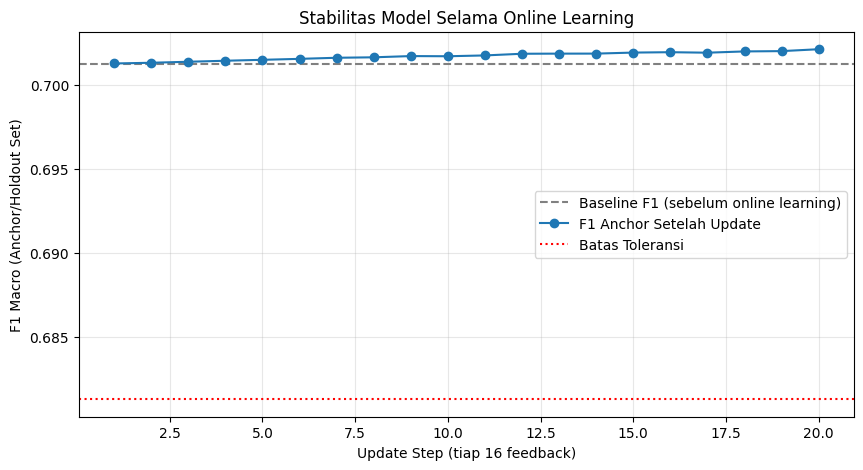

In [50]:
import matplotlib.pyplot as plt

df_history = pd.DataFrame(anchor_history)

plt.figure(figsize=(10, 5))
plt.axhline(y=anchor_f1_before, color='gray', linestyle='--', label='Baseline F1 (sebelum online learning)')
plt.plot(df_history["update_step"], df_history["f1_macro"], marker='o', label='F1 Anchor Setelah Update')
plt.axhline(y=anchor_f1_before - FORGETTING_THRESHOLD, color='red', linestyle=':', label='Batas Toleransi')
plt.xlabel("Update Step (tiap 16 feedback)")
plt.ylabel("F1 Macro (Anchor/Holdout Set)")
plt.title("Stabilitas Model Selama Online Learning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [51]:
online_learning_dir = "/content/online_learning_ready"

torch.save({
    "model_state_dict": model.state_dict(),
    "baseline_state_dict": baseline_model_state,
    "anchor_f1_before": anchor_f1_before,
    "anchor_f1_after_stress_test": df_history["f1_macro"].iloc[-1],
    "hidden_dim": 128, "num_classes": 3, "dropout": 0.3, "pad_idx": PAD_IDX,
}, f"{online_learning_dir}/online_learning_final_checkpoint.pt")

df_history.to_csv(f"{online_learning_dir}/anchor_stability_history.csv", index=False)

import shutil
from google.colab import files
shutil.make_archive("/content/online_learning_checkpoint", "zip", online_learning_dir)
files.download("/content/online_learning_checkpoint.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **EBSCAP 20: Konversi model PyTorch ke format ONNX Runtime**

In [65]:
!pip install onnx onnxruntime -q

In [65]:
!pip install onnxscript -q

In [57]:
import torch

checkpoint = torch.load(
    "/content/online_learning_ready/online_learning_final_checkpoint.pt",
    map_location=device,
    weights_only=False
)

model = BiLSTMAttentionClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=checkpoint["hidden_dim"],
    num_classes=checkpoint["num_classes"],
    dropout=checkpoint["dropout"],
    pad_idx=checkpoint["pad_idx"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model berhasil di-load, siap dikonversi ke ONNX.")

Model berhasil di-load, siap dikonversi ke ONNX.


In [58]:
import torch.nn as nn

class InferenceWrapper(nn.Module):
    """Wrapper supaya output ONNX cuma logits, bukan tuple (logits, attn_weights)."""
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        logits, _ = self.base_model(x)
        return logits

inference_model = InferenceWrapper(model).to(device)
inference_model.eval()

InferenceWrapper(
  (base_model): BiLSTMAttentionClassifier(
    (embedding): Embedding(47016, 100, padding_idx=0)
    (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
    (attention): Attention(
      (attn): Linear(in_features=256, out_features=1, bias=True)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (fc): Linear(in_features=256, out_features=3, bias=True)
  )
)

In [64]:
import os

onnx_dir = "/content/onnx_ready"
os.makedirs(onnx_dir, exist_ok=True)

# Dummy input — bentuknya harus sama persis dengan input asli: [batch_size, MAX_LEN]
dummy_input = torch.randint(0, embedding_matrix.shape[0], (1, MAX_LEN), dtype=torch.long).to(device)

onnx_path = f"{onnx_dir}/sentiment_model.onnx"

torch.onnx.export(
    inference_model,
    dummy_input,
    onnx_path,
    input_names=["input_ids"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size"},   # batch size fleksibel (1 request maupun banyak sekaligus)
        "logits": {0: "batch_size"}
    },
    opset_version=14,
    do_constant_folding=True
)

print(f"Model ONNX tersimpan di: {onnx_path}")
print(f"Ukuran file: {os.path.getsize(onnx_path) / (1024**2):.2f} MB")

/tmp/ipykernel_628/3623508967.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0906 14:22:21.546000 628 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `InferenceWrapper([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.13/contextlib.py:148: UserWarning: The tensor attributes self.base_model.lstm._flat_weights[0], self.base_model.lstm._flat_weights[1], self.base_model.lstm._flat_weights[2], self.base_model.lstm._flat_weights[3], self.base_model.lstm._flat_weights[4], self.base_model.lstm._flat_weights[5], self.base_model.lstm._flat_weights[6], self.base_model.lstm._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `InferenceWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model ONNX tersimpan di: /content/onnx_ready/sentiment_model.onnx
Ukuran file: 0.07 MB


In [66]:
import onnxruntime as ort
import numpy as np

# Load ONNX model
ort_session = ort.InferenceSession(onnx_path)

# Sample test — pakai beberapa data asli dari test set
test_sample = X_test[:5]  # 5 baris pertama

# Prediksi PyTorch (source of truth)
with torch.no_grad():
    x_tensor = torch.tensor(test_sample, dtype=torch.long).to(device)
    pytorch_logits = inference_model(x_tensor).cpu().numpy()

# Prediksi ONNX
onnx_input = {"input_ids": test_sample.astype(np.int64)}
onnx_logits = ort_session.run(["logits"], onnx_input)[0]

# Bandingkan
max_diff = np.abs(pytorch_logits - onnx_logits).max()
print(f"Selisih maksimum antara PyTorch dan ONNX: {max_diff:.8f}")

if max_diff < 1e-4:
    print("✅ Validasi berhasil — output ONNX identik dengan PyTorch (dalam toleransi floating point).")
else:
    print("⚠️ WARNING — selisih signifikan, perlu investigasi lebih lanjut.")

# Cek juga hasil prediksi kelas (argmax) sama persis
pytorch_preds = np.argmax(pytorch_logits, axis=1)
onnx_preds = np.argmax(onnx_logits, axis=1)
print(f"PyTorch predictions: {pytorch_preds}")
print(f"ONNX predictions:    {onnx_preds}")
print(f"Match: {np.array_equal(pytorch_preds, onnx_preds)}")

Selisih maksimum antara PyTorch dan ONNX: 0.00000238
✅ Validasi berhasil — output ONNX identik dengan PyTorch (dalam toleransi floating point).
PyTorch predictions: [2 0 2 2 2]
ONNX predictions:    [2 0 2 2 2]
Match: True


In [67]:
import time

batch_test = X_test[:100]

# Benchmark PyTorch
x_tensor = torch.tensor(batch_test, dtype=torch.long).to(device)
start = time.time()
with torch.no_grad():
    for _ in range(20):
        _ = inference_model(x_tensor)
pytorch_time = (time.time() - start) / 20

# Benchmark ONNX
onnx_input_batch = {"input_ids": batch_test.astype(np.int64)}
start = time.time()
for _ in range(20):
    _ = ort_session.run(["logits"], onnx_input_batch)
onnx_time = (time.time() - start) / 20

print(f"Rata-rata waktu inferensi PyTorch (100 samples): {pytorch_time*1000:.2f} ms")
print(f"Rata-rata waktu inferensi ONNX (100 samples):    {onnx_time*1000:.2f} ms")
print(f"Speedup: {pytorch_time/onnx_time:.2f}x")

Rata-rata waktu inferensi PyTorch (100 samples): 444.38 ms
Rata-rata waktu inferensi ONNX (100 samples):    217.51 ms
Speedup: 2.04x
